### Importing required data sources & Viewing data for ECB data

In [52]:
# ECB API data
import os
import certifi
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO # Will turn the string to a file like object

# Fix my SSL certificate issue
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

# ECB URL - Coming from the European Central Bank (ECB) Data Warehouse / Data Portal API.
url = "https://data-api.ecb.europa.eu/service/data/FM/B.U2.EUR.4F.KR.DFR.LEV?format=csvdata"

# Getting data from ECB
response = requests.get(url)
response.raise_for_status()

# Turn the text 'response' into a DataFrame
df_ecb = pd.read_csv(StringIO(response.text)) # Moves data to pandas

In [53]:
df_ecb.shape

(67, 40)

In [54]:
print(df_ecb.head())

                         KEY FREQ REF_AREA CURRENCY PROVIDER_FM INSTRUMENT_FM  \
0  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
1  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
2  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
3  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
4  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   

  PROVIDER_FM_ID DATA_TYPE_FM TIME_PERIOD  OBS_VALUE  ... UNIT_INDEX_BASE  \
0            DFR          LEV  1999-01-01       2.00  ...             NaN   
1            DFR          LEV  1999-01-04       2.75  ...             NaN   
2            DFR          LEV  1999-01-22       2.00  ...             NaN   
3            DFR          LEV  1999-04-09       1.50  ...             NaN   
4            DFR          LEV  1999-11-05       2.00  ...             NaN   

  COMPILATION  COVERAGE  DECIMALS SOURCE_AGENCY  S

In [55]:
print(df_ecb.columns)

Index(['KEY', 'FREQ', 'REF_AREA', 'CURRENCY', 'PROVIDER_FM', 'INSTRUMENT_FM',
       'PROVIDER_FM_ID', 'DATA_TYPE_FM', 'TIME_PERIOD', 'OBS_VALUE',
       'OBS_STATUS', 'OBS_CONF', 'OBS_PRE_BREAK', 'OBS_COM', 'TIME_FORMAT',
       'BREAKS', 'COLLECTION', 'COMPILING_ORG', 'DISS_ORG', 'DOM_SER_IDS',
       'FM_CONTRACT_TIME', 'FM_COUPON_RATE', 'FM_IDENTIFIER', 'FM_LOT_SIZE',
       'FM_MATURITY', 'FM_OUTS_AMOUNT', 'FM_PUT_CALL', 'FM_STRIKE_PRICE',
       'PUBL_MU', 'PUBL_PUBLIC', 'UNIT_INDEX_BASE', 'COMPILATION', 'COVERAGE',
       'DECIMALS', 'SOURCE_AGENCY', 'SOURCE_PUB', 'TITLE', 'TITLE_COMPL',
       'UNIT', 'UNIT_MULT'],
      dtype='object')


In [56]:
df_ecb.isnull().sum()

KEY                  0
FREQ                 0
REF_AREA             0
CURRENCY             0
PROVIDER_FM          0
INSTRUMENT_FM        0
PROVIDER_FM_ID       0
DATA_TYPE_FM         0
TIME_PERIOD          0
OBS_VALUE            0
OBS_STATUS           0
OBS_CONF             0
OBS_PRE_BREAK       67
OBS_COM             67
TIME_FORMAT          0
BREAKS              67
COLLECTION           0
COMPILING_ORG       67
DISS_ORG            67
DOM_SER_IDS         67
FM_CONTRACT_TIME    67
FM_COUPON_RATE      67
FM_IDENTIFIER       67
FM_LOT_SIZE         67
FM_MATURITY         67
FM_OUTS_AMOUNT      67
FM_PUT_CALL         67
FM_STRIKE_PRICE     67
PUBL_MU             67
PUBL_PUBLIC         67
UNIT_INDEX_BASE     67
COMPILATION         67
COVERAGE            67
DECIMALS             0
SOURCE_AGENCY       67
SOURCE_PUB          67
TITLE                0
TITLE_COMPL          0
UNIT                 0
UNIT_MULT            0
dtype: int64

In [57]:
df_ecb.describe()

,OBS_VALUE,OBS_PRE_BREAK,OBS_COM,BREAKS,COMPILING_ORG,DISS_ORG,DOM_SER_IDS,FM_CONTRACT_TIME,FM_COUPON_RATE,FM_IDENTIFIER,...,FM_STRIKE_PRICE,PUBL_MU,PUBL_PUBLIC,UNIT_INDEX_BASE,COMPILATION,COVERAGE,DECIMALS,SOURCE_AGENCY,SOURCE_PUB,UNIT_MULT
count,67.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,67.0,0.0,0.0,67.0
mean,1.962687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
std,1.279688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
min,-0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
25%,0.875000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
50%,2.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
75%,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
max,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0


In [58]:
df_ecb['OBS_VALUE']

0     2.00
1     2.75
2     2.00
3     1.50
4     2.00
      ... 
62    3.00
63    2.75
64    2.50
65    2.25
66    2.00
Name: OBS_VALUE, Length: 67, dtype: float64

In [59]:
df_ecb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 40 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   KEY               67 non-null     object 
 1   FREQ              67 non-null     object 
 2   REF_AREA          67 non-null     object 
 3   CURRENCY          67 non-null     object 
 4   PROVIDER_FM       67 non-null     object 
 5   INSTRUMENT_FM     67 non-null     object 
 6   PROVIDER_FM_ID    67 non-null     object 
 7   DATA_TYPE_FM      67 non-null     object 
 8   TIME_PERIOD       67 non-null     object 
 9   OBS_VALUE         67 non-null     float64
 10  OBS_STATUS        67 non-null     object 
 11  OBS_CONF          67 non-null     object 
 12  OBS_PRE_BREAK     0 non-null      float64
 13  OBS_COM           0 non-null      float64
 14  TIME_FORMAT       67 non-null     object 
 15  BREAKS            0 non-null      float64
 16  COLLECTION        67 non-null     object 
 17 

In [60]:
df_ecb.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
62    False
63    False
64    False
65    False
66    False
Length: 67, dtype: bool

In [61]:
df_ecb['OBS_VALUE'].duplicated().any() # This kind of data should have duplicates becuase this is for all of europe.

np.True_

In [62]:
df_ecb['OBS_VALUE'].dtypes

dtype('float64')

In [63]:
df_ecb['TIME_PERIOD'].dtypes

dtype('O')

In [64]:
df_ecb['TIME_PERIOD']

0     1999-01-01
1     1999-01-04
2     1999-01-22
3     1999-04-09
4     1999-11-05
         ...    
62    2024-12-18
63    2025-02-05
64    2025-03-12
65    2025-04-23
66    2025-06-11
Name: TIME_PERIOD, Length: 67, dtype: object

In [65]:
df_ecb['TIME_PERIOD'].min()

'1999-01-01'

----

## Data Wrangling

In [66]:
df_ecb['TIME_PERIOD'] = pd.to_datetime(df_ecb['TIME_PERIOD'])

df_ecb = df_ecb[(df_ecb['TIME_PERIOD'] >= '2015-01-01') & (df_ecb['TIME_PERIOD'] <= '2023-12-31')]

In [67]:
# Chaning date format
df_ecb['TIME_PERIOD'] = pd.to_datetime(df_ecb['TIME_PERIOD']).dt.strftime('%Y-%m')
df_ecb['TIME_PERIOD'].values

array(['2015-12', '2016-03', '2019-09', '2022-07', '2022-09', '2022-11',
       '2022-12', '2023-02', '2023-03', '2023-05', '2023-06', '2023-08',
       '2023-09'], dtype=object)

In [68]:
# Removing everything expect the data and 'OBS_VALUE'
df_ecb = df_ecb[[ "TIME_PERIOD", "OBS_VALUE"]]

df_ecb = df_ecb.rename(columns={"TIME_PERIOD": "date","OBS_VALUE": "interest"})

In [69]:
df_ecb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 46 to 58
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      13 non-null     object 
 1   interest  13 non-null     float64
dtypes: float64(1), object(1)
memory usage: 312.0+ bytes


In [70]:
df_ecb.isnull().sum()

date        0
interest    0
dtype: int64

In [71]:
df_ecb.head()

,date,interest
46,2015-12,-0.30
47,2016-03,-0.40
48,2019-09,-0.50
49,2022-07,0.00
50,2022-09,0.75


In [72]:
df_ecb.to_csv("interest_clean.csv", index=False)

In [73]:
df_ecb.head()

,date,interest
46,2015-12,-0.30
47,2016-03,-0.40
48,2019-09,-0.50
49,2022-07,0.00
50,2022-09,0.75


----

####  Visualization for ECB & what it shows 

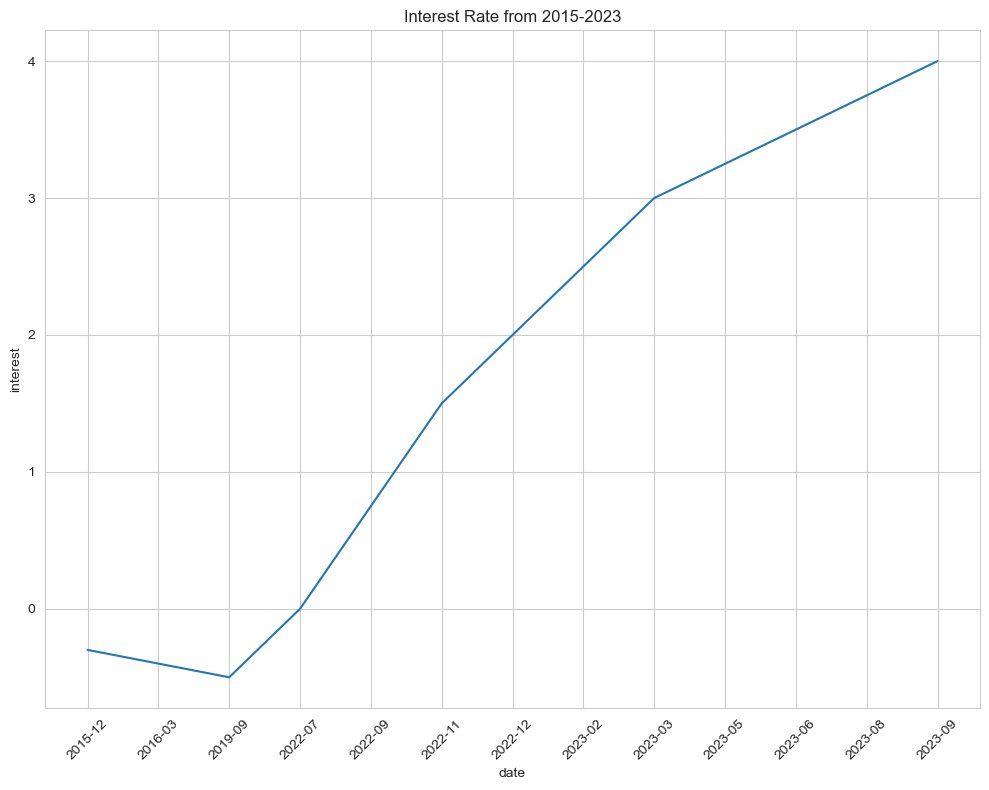

In [74]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,8))
sns.lineplot(data=df_ecb, x='date', y='interest')

plt.xticks(rotation=45)
plt.title('Interest Rate from 2015-2023')
plt.tight_layout()
plt.show()

##### What this graph shows - 
#### Interest rates rise sharply (2022–2023) -- this is a reaction to inflation


----


## Energy rates data

#### Viewing the data

In [75]:
energy_url = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/nrg_pc_204/1.0/*.*.*.*.*.*.*?c[freq]=S&c[siec]=E7000&c[nrg_cons]=KWH_LT1000,KWH1000-2499,KWH2500-4999,KWH5000-14999,KWH_GE15000&c[unit]=KWH&c[tax]=X_TAX,X_VAT,I_TAX&c[currency]=EUR,PPS,NAC&c[geo]=EU27_2020,EA,BE,BG,CZ,DK,DE,EE,IE,EL,ES,FR,HR,IT,CY,LV,LT,LU,HU,MT,NL,AT,PL,PT,RO,SI,SK,FI,SE,IS,LI,NO,UK,BA,ME,MD,MK,GE,AL,RS,TR,UA,XK&c[TIME_PERIOD]=2025-S2,2025-S1,2024-S2,2024-S1,2023-S2,2023-S1,2022-S2,2022-S1,2021-S2,2021-S1,2020-S2,2020-S1,2019-S2,2019-S1,2018-S2,2018-S1,2017-S2,2017-S1,2016-S2,2016-S1,2015-S2,2015-S1,2014-S2&compress=false&format=csvdata&formatVersion=1.0&lang=en&labels=label_only"
df_energy = pd.read_csv(energy_url)

df_energy.head(5)

,DATAFLOW,LAST UPDATE,freq,siec,nrg_cons,unit,tax,currency,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:NRG_PC_204(1.0),10/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 1 000 kWh to 2 499 kWh - band DB,Kilowatt-hour,All taxes and levies included,Euro,Albania,2014-S2,0.1160,NaN,NaN
1,ESTAT:NRG_PC_204(1.0),10/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 1 000 kWh to 2 499 kWh - band DB,Kilowatt-hour,All taxes and levies included,Euro,Albania,2015-S1,0.0812,NaN,NaN
2,ESTAT:NRG_PC_204(1.0),10/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 1 000 kWh to 2 499 kWh - band DB,Kilowatt-hour,All taxes and levies included,Euro,Albania,2015-S2,0.0819,NaN,NaN
3,ESTAT:NRG_PC_204(1.0),10/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 1 000 kWh to 2 499 kWh - band DB,Kilowatt-hour,All taxes and levies included,Euro,Albania,2016-S1,0.0824,NaN,NaN
4,ESTAT:NRG_PC_204(1.0),10/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 1 000 kWh to 2 499 kWh - band DB,Kilowatt-hour,All taxes and levies included,Euro,Albania,2016-S2,0.0835,NaN,NaN


In [76]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40230 entries, 0 to 40229
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATAFLOW     40230 non-null  object 
 1   LAST UPDATE  40230 non-null  object 
 2   freq         40230 non-null  object 
 3   siec         40230 non-null  object 
 4   nrg_cons     40230 non-null  object 
 5   unit         40230 non-null  object 
 6   tax          40230 non-null  object 
 7   currency     40230 non-null  object 
 8   geo          40230 non-null  object 
 9   TIME_PERIOD  40230 non-null  object 
 10  OBS_VALUE    40230 non-null  float64
 11  OBS_FLAG     1205 non-null   object 
 12  CONF_STATUS  0 non-null      float64
dtypes: float64(2), object(11)
memory usage: 4.0+ MB


In [77]:
df_energy.describe()

,OBS_VALUE,CONF_STATUS
count,40230.000000,0.0
mean,0.989840,NaN
std,4.141814,NaN
min,-3.514400,NaN
25%,0.130700,NaN
50%,0.185500,NaN
75%,0.285300,NaN
max,66.530000,NaN


In [78]:
df_energy.isnull().sum()

DATAFLOW           0
LAST UPDATE        0
freq               0
siec               0
nrg_cons           0
unit               0
tax                0
currency           0
geo                0
TIME_PERIOD        0
OBS_VALUE          0
OBS_FLAG       39025
CONF_STATUS    40230
dtype: int64

In [79]:
df_energy['geo'].unique()

array(['Albania', 'Austria', 'Bosnia and Herzegovina', 'Belgium',
       'Bulgaria', 'Cyprus', 'Czechia', 'Germany', 'Denmark',
       'Euro area (EA11-1999, EA12-2001, EA13-2007, EA15-2008, EA16-2009, EA17-2011, EA18-2014, EA19-2015, EA20-2023, EA21-2026)',
       'Estonia', 'Greece', 'Spain',
       'European Union - 27 countries (from 2020)', 'Finland', 'France',
       'Georgia', 'Croatia', 'Hungary', 'Ireland', 'Iceland', 'Italy',
       'Liechtenstein', 'Lithuania', 'Luxembourg', 'Latvia', 'Moldova',
       'Montenegro', 'North Macedonia', 'Malta', 'Netherlands', 'Norway',
       'Poland', 'Portugal', 'Romania', 'Serbia', 'Sweden', 'Slovenia',
       'Slovakia', 'Türkiye', 'Ukraine', 'United Kingdom', 'Kosovo*'],
      dtype=object)

In [80]:
df_energy['LAST UPDATE'].unique()

array(['10/04/26 23:00:00'], dtype=object)

In [81]:
df_energy['TIME_PERIOD'].unique()

array(['2014-S2', '2015-S1', '2015-S2', '2016-S1', '2016-S2', '2017-S1',
       '2017-S2', '2018-S2', '2019-S1', '2019-S2', '2020-S1', '2020-S2',
       '2021-S1', '2021-S2', '2022-S1', '2022-S2', '2023-S1', '2023-S2',
       '2024-S1', '2024-S2', '2025-S1', '2018-S1', '2025-S2'],
      dtype=object)

-----


In [82]:
# Changing columns
df_energy.columns = df_energy.columns.str.replace(' ', '_')
df_energy.columns = map(str.lower, df_energy.columns)
df_energy.head()


,dataflow,last_update,freq,siec,nrg_cons,unit,tax,currency,geo,time_period,obs_value,obs_flag,conf_status
0,ESTAT:NRG_PC_204(1.0),10/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 1 000 kWh to 2 499 kWh - band DB,Kilowatt-hour,All taxes and levies included,Euro,Albania,2014-S2,0.1160,NaN,NaN
1,ESTAT:NRG_PC_204(1.0),10/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 1 000 kWh to 2 499 kWh - band DB,Kilowatt-hour,All taxes and levies included,Euro,Albania,2015-S1,0.0812,NaN,NaN
2,ESTAT:NRG_PC_204(1.0),10/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 1 000 kWh to 2 499 kWh - band DB,Kilowatt-hour,All taxes and levies included,Euro,Albania,2015-S2,0.0819,NaN,NaN
3,ESTAT:NRG_PC_204(1.0),10/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 1 000 kWh to 2 499 kWh - band DB,Kilowatt-hour,All taxes and levies included,Euro,Albania,2016-S1,0.0824,NaN,NaN
4,ESTAT:NRG_PC_204(1.0),10/04/26 23:00:00,"Half-yearly, semesterly",Electricity,Consumption from 1 000 kWh to 2 499 kWh - band DB,Kilowatt-hour,All taxes and levies included,Euro,Albania,2016-S2,0.0835,NaN,NaN


In [83]:
# Rename
df_energy = df_energy.rename(columns={"geo": "country", "time_period": "date", "obs_value": "energy"})

# Keep only needed columns
df_energy = df_energy[[ "date", "country", 'energy']]


df_energy.head()

,date,country,energy
0,2014-S2,Albania,0.1160
1,2015-S1,Albania,0.0812
2,2015-S2,Albania,0.0819
3,2016-S1,Albania,0.0824
4,2016-S2,Albania,0.0835


In [84]:
for i in df_energy:
  print(df_energy['country'].unique())

['Albania' 'Austria' 'Bosnia and Herzegovina' 'Belgium' 'Bulgaria'
 'Cyprus' 'Czechia' 'Germany' 'Denmark'
 'Euro area (EA11-1999, EA12-2001, EA13-2007, EA15-2008, EA16-2009, EA17-2011, EA18-2014, EA19-2015, EA20-2023, EA21-2026)'
 'Estonia' 'Greece' 'Spain' 'European Union - 27 countries (from 2020)'
 'Finland' 'France' 'Georgia' 'Croatia' 'Hungary' 'Ireland' 'Iceland'
 'Italy' 'Liechtenstein' 'Lithuania' 'Luxembourg' 'Latvia' 'Moldova'
 'Montenegro' 'North Macedonia' 'Malta' 'Netherlands' 'Norway' 'Poland'
 'Portugal' 'Romania' 'Serbia' 'Sweden' 'Slovenia' 'Slovakia' 'Türkiye'
 'Ukraine' 'United Kingdom' 'Kosovo*']
['Albania' 'Austria' 'Bosnia and Herzegovina' 'Belgium' 'Bulgaria'
 'Cyprus' 'Czechia' 'Germany' 'Denmark'
 'Euro area (EA11-1999, EA12-2001, EA13-2007, EA15-2008, EA16-2009, EA17-2011, EA18-2014, EA19-2015, EA20-2023, EA21-2026)'
 'Estonia' 'Greece' 'Spain' 'European Union - 27 countries (from 2020)'
 'Finland' 'France' 'Georgia' 'Croatia' 'Hungary' 'Ireland' 'Iceland'
 '

In [85]:
# Filter countries
df_energy = df_energy[df_energy["country"].isin(["Germany","Spain","France","Italy"])]

for i in df_energy:
  print(df_energy['country'].unique())

['Germany' 'Spain' 'France' 'Italy']
['Germany' 'Spain' 'France' 'Italy']
['Germany' 'Spain' 'France' 'Italy']


In [86]:
# Changing country names

country_names = {"Germany": "DE","Spain": "ES", "France": "FR","Italy": "IT"}

df_energy["country"] = df_energy["country"].replace(country_names)

In [87]:
# Fix date types in a function -- my data is not monthly so I need to fill the dates in to work with what we have
def convert_halfyear_to_month(period):
    period = str(period)
    if "S1" in period:
        return period[:4] + "-01"
    elif "S2" in period:
        return period[:4] + "-07"
    return None

df_energy["date"] = df_energy["date"].apply(convert_halfyear_to_month)
df_energy["date"] = pd.to_datetime(df_energy["date"]).dt.to_period("M")

In [ ]:
'''
Trying something new to get a a better reading on the month by month reading
'''
# Remove duplicates
df_energy = df_energy.groupby(["country", "date"], as_index=False)["energy"].mean()

# Convert Period → datetime
df_energy["date"] = df_energy["date"].dt.to_timestamp()

# Resample monthly
df_energy = (
    df_energy
    .set_index("date")
    .groupby("country")["energy"]
    .resample("MS")
    .asfreq()
    .reset_index()
)

# Interpolate
df_energy["energy"] = df_energy["energy"].interpolate()

# Convert back
df_energy["date"] = df_energy["date"].dt.to_period("M")

In [89]:
print(df_energy["date"].dtype)

period[M]


In [90]:
df_energy.head()

,country,date,energy
0,DE,2014-07,0.248944
1,DE,2014-08,0.248793
2,DE,2014-09,0.248641
3,DE,2014-10,0.248489
4,DE,2014-11,0.248337


In [91]:
df_energy.isnull().sum()

country    0
date       0
energy     0
dtype: int64

In [92]:
df_energy

,country,date,energy
0,DE,2014-07,0.248944
1,DE,2014-08,0.248793
2,DE,2014-09,0.248641
3,DE,2014-10,0.248489
4,DE,2014-11,0.248337
...,...,...,...
521,IT,2025-03,0.338497
522,IT,2025-04,0.332652
523,IT,2025-05,0.326807
524,IT,2025-06,0.320963


In [93]:
df_energy.to_csv("energy_clean.csv", index=False)

----

#### Visuals for dataset

<Axes: xlabel='date', ylabel='country'>

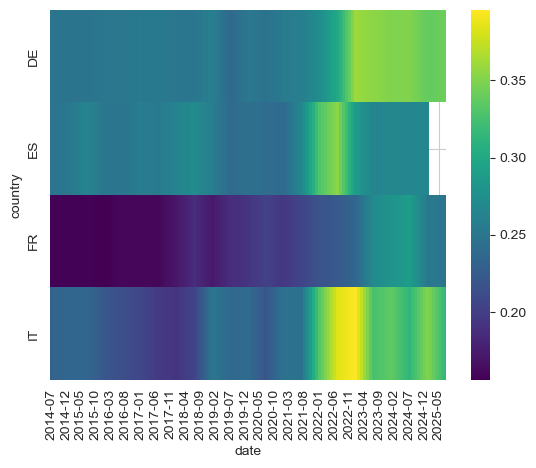

In [94]:
pivot = df_energy.pivot_table(index="country", columns="date", values="energy")
sns.heatmap(pivot, cmap="viridis")

<Axes: xlabel='country', ylabel='energy'>

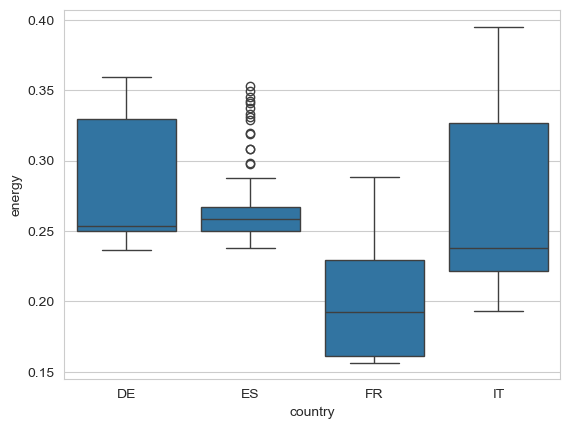

In [95]:
sns.boxplot(data=df_energy, x="country", y="energy")

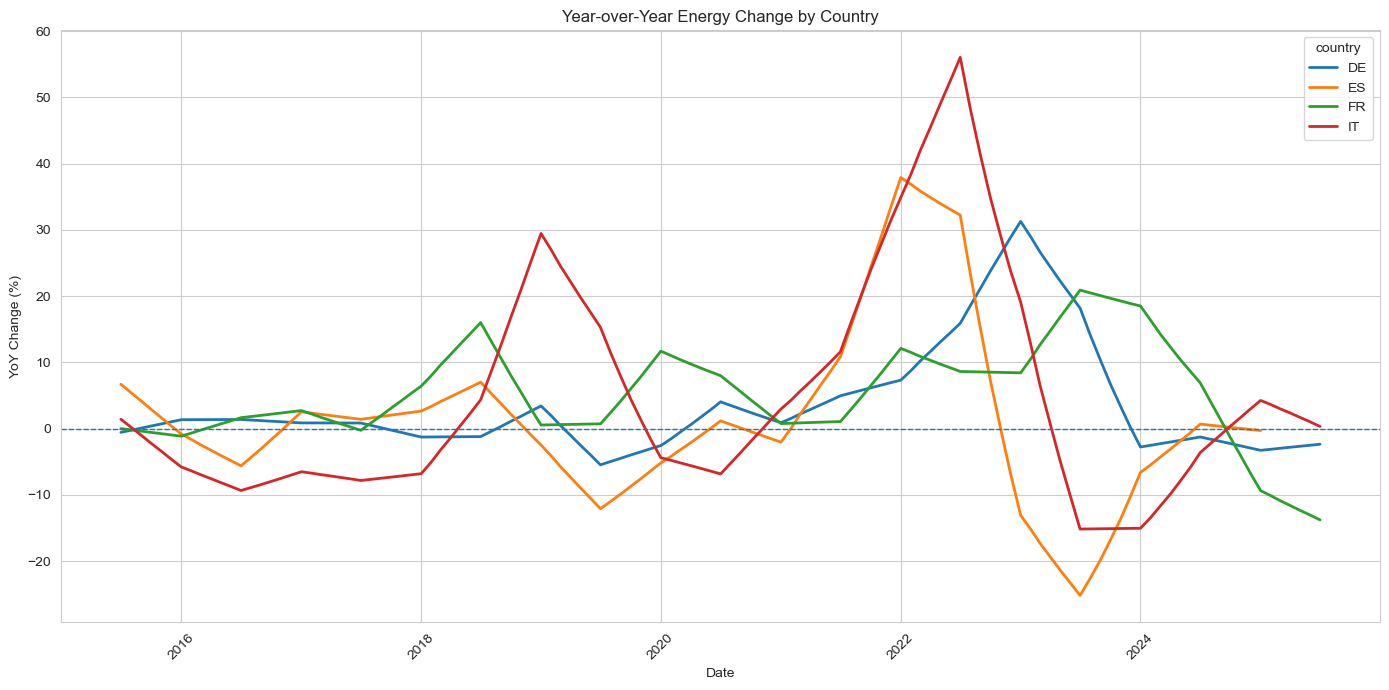

In [97]:
df_growth = df_energy.copy()
df_growth = df_growth.sort_values(["country", "date"])

df_growth["energy_yoy_pct"] = (
    df_growth.groupby("country")["energy"].pct_change(periods=12) * 100
)

# Convert Period[M] to datetime for plotting
df_growth["date"] = df_growth["date"].dt.to_timestamp()

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=df_growth,
    x="date",
    y="energy_yoy_pct",
    hue="country",
    linewidth=2
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Year-over-Year Energy Change by Country")
plt.xlabel("Date")
plt.ylabel("YoY Change (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()